# Bacteria Doubling: From a Curve to a Straight Line

**A beginner-friendly univariate regression example and code walkthrough.**

When bacteria reproduce, a larger population produces more new bacteria. In an ideal doubling example: **2 → 4 → 8 → 16 → 32** over equal time intervals. This is multiplication rather than adding the same amount each time.

**This dataset is synthetic**, created for learning; it is not a laboratory experiment. Population is measured in **thousands of bacteria**, so a value of 2 means 2,000 bacteria. We assume favorable conditions during a short six-hour period. Real populations cannot grow exponentially forever.

We will compare a straight-line model with a model trained on the natural logarithm of population, then prepare three talking points.

## 1. Setup
Run cells from top to bottom in VS Code or Jupyter. If needed, uncomment the installation line below and restart your kernel afterward.

In [1]:
# Install these packages only if they are missing in your Python environment.
# %pip install numpy pandas matplotlib scikit-learn

from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})

## 2. Load the example dataset

The CSV is embedded below so this notebook works by itself. The separate CSV contains the same values.

| Column | Meaning | Role |
|---|---|---|
| `time_hours` | Hours since the experiment started | Independent variable, X |
| `population_thousands` | Simulated population in thousands | Dependent variable, y |

The simulation used $y = 2e^{0.70x}$ with small random multiplicative variation. The value 0.70 is a continuous growth rate per hour; it is not a 70% hourly increase. The ideal population multiplies by $e^{0.70} ≈ 2.01$ each hour.

In [2]:
# Read the embedded CSV into a DataFrame.
csv_text = 'time_hours,population_thousands\n0.0,2.049354\n0.2,2.116891\n0.4,2.809997\n0.6,3.281801\n0.8,2.99536\n1.0,3.629057\n1.2,4.680357\n1.4,5.195785\n1.6,6.121475\n1.8,6.58572\n2.0,8.701531\n2.2,9.928114\n2.4,10.787949\n2.6,13.508599\n2.8,14.73975\n3.0,15.247321\n3.2,19.349126\n3.4,20.014091\n3.6,26.666903\n3.8,28.478605\n4.0,32.406473\n4.2,35.825962\n4.4,47.987976\n4.6,49.441236\n4.8,55.638809\n5.0,64.391169\n5.2,79.498004\n5.4,90.231871\n5.6,104.184753\n5.8,120.014535\n6.0,158.297946\n'
df = pd.read_csv(StringIO(csv_text))

# To use the separate file instead, replace the line above with:
# df = pd.read_csv("bacteria_doubling_data.csv")

print(f"Rows: {len(df)}")
display(df.head(10))

Rows: 31


,time_hours,population_thousands
0,0.0,2.049354
1,0.2,2.116891
2,0.4,2.809997
3,0.6,3.281801
4,0.8,2.995360
5,1.0,3.629057
6,1.2,4.680357
7,1.4,5.195785
8,1.6,6.121475
9,1.8,6.585720


In [3]:
# The natural logarithm requires strictly positive population values.
assert not df.isna().any().any(), "Missing values must be handled first."
assert (df["population_thousands"] > 0).all(), "Logarithms need positive values."
display(df.describe().round(3))

,time_hours,population_thousands
count,31.000,31.000
mean,3.000,33.703
std,1.818,39.702
min,0.000,2.049
25%,1.500,5.659
50%,3.000,15.247
75%,4.500,48.715
max,6.000,158.298


## 3. See the growth pattern
The dashed curve is the ideal simulated pattern. The dots include small variations. Notice how the population increases by larger amounts as time passes.

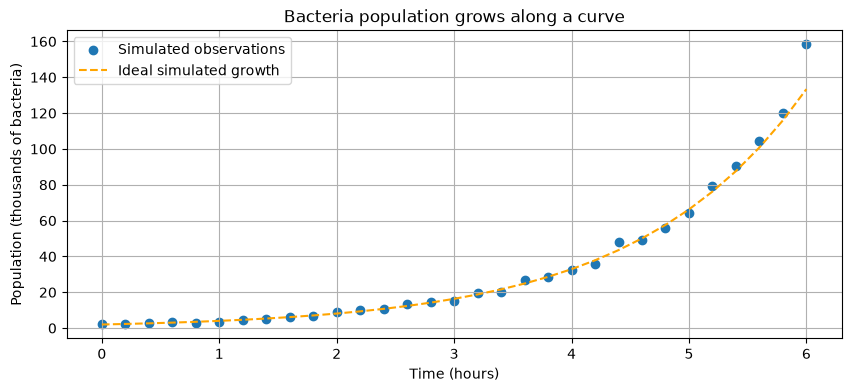

In [4]:
# Show observed data and the known pattern used to simulate them.
plt.scatter(df["time_hours"], df["population_thousands"], label="Simulated observations")
plt.plot(df["time_hours"], 2 * np.exp(0.70 * df["time_hours"]),
         "--", color="orange", label="Ideal simulated growth")
plt.xlabel("Time (hours)")
plt.ylabel("Population (thousands of bacteria)")
plt.title("Bacteria population grows along a curve")
plt.legend()
plt.show()

## 4. Transform the curve

The natural logarithm compresses large values. Equal multiplications become equal additions. For example, doubling adds the same amount, $\ln(2)$, on the log scale.

$$y = ae^{bx} \quad\Longrightarrow\quad \ln(y) = \ln(a) + bx$$

The right side is a straight-line equation. We still use just **one input variable: time**. Only the target changes from population to log-population.

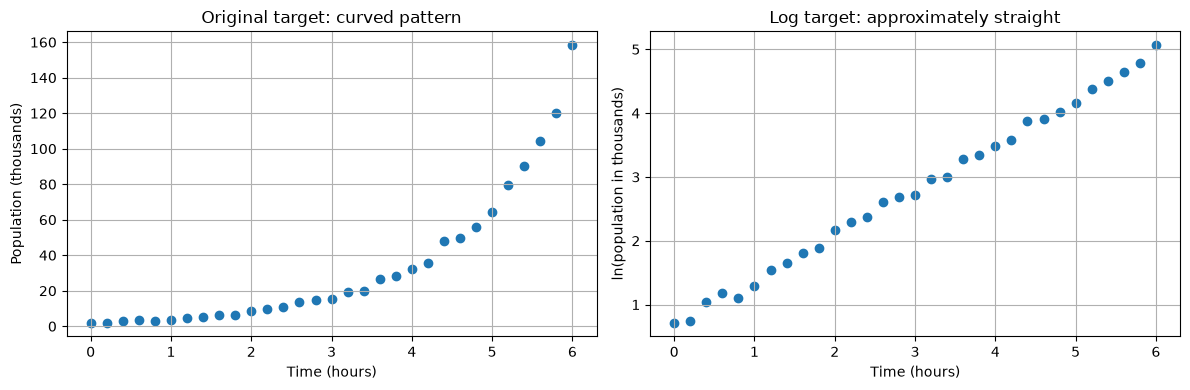

In [5]:
# Create the transformed target without replacing the original population.
df["log_population"] = np.log(df["population_thousands"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df["time_hours"], df["population_thousands"])
axes[0].set(title="Original target: curved pattern", xlabel="Time (hours)",
            ylabel="Population (thousands)")
axes[1].scatter(df["time_hours"], df["log_population"])
axes[1].set(title="Log target: approximately straight", xlabel="Time (hours)",
            ylabel="ln(population in thousands)")
plt.tight_layout()
plt.show()

## 5. Reserve data for evaluation
Training data teach the models. Test data check predictions on observations the models have not seen. Both models use exactly the same split. This random split evaluates predictions within this six-hour range; it does not prove that the models can forecast future growth.

In [6]:
# Double brackets keep X two-dimensional, as scikit-learn expects.
X = df[["time_hours"]]
y = df["population_thousands"]

# Reserve 25% of observations; the seed makes results reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

Training observations: 23
Test observations: 8


## 6. Train two models
**Model A:** fits a straight line directly to population.  
**Model B:** fits a straight line to log-population. We then use `np.exp()` to convert predictions back to the original population scale.

In [7]:
# Model A learns population = intercept + slope * time.
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

# Model B learns ln(population) = intercept + slope * time.
log_model = LinearRegression()
log_model.fit(X_train, np.log(y_train))
log_predictions = log_model.predict(X_test)

# Undo the logarithm to express predictions in thousands of bacteria.
exponential_predictions = np.exp(log_predictions)

Exponentiating a fitted log prediction gives the fitted central growth curve; it is not automatically an unbiased estimate of mean population when there is noise. For this introductory example we compare that curve directly with observations.

In [8]:
# Recover the parameters of the exponential growth curve.
estimated_a = np.exp(log_model.intercept_)
estimated_b = log_model.coef_[0]

print(f"Straight line: population = {linear_model.intercept_:.3f} "
      f"+ {linear_model.coef_[0]:.3f} * time")
print(f"Exponential curve: population = {estimated_a:.3f} "
      f"* exp({estimated_b:.3f} * time)")

# The doubling time is the time needed for the population to multiply by 2.
if estimated_b > 0:
    print(f"Estimated doubling time: {np.log(2) / estimated_b:.3f} hours")
print(f"Simulation doubling time: {np.log(2) / 0.70:.3f} hours")

Straight line: population = -19.168 + 17.929 * time
Exponential curve: population = 1.957 * exp(0.715 * time)
Estimated doubling time: 0.970 hours
Simulation doubling time: 0.990 hours


## 7. Compare predictions fairly
Both models are evaluated on the **same test observations and original population scale**.

- **RMSE:** prediction error size in thousands of bacteria; lower is better.
- **R²:** performance relative to predicting the test mean; closer to 1 is better. It can be negative and is not a percentage of accuracy.

Do not compare R² on population with R² on log-population as if they measured the same target.

In [9]:
# Calculate identical metrics for both models on the original scale.
results = []
for name, predictions in [
    ("Straight-line regression", linear_predictions),
    ("Log-transformed regression", exponential_predictions)
]:
    results.append({
        "Model": name,
        "Test RMSE (thousands)": np.sqrt(mean_squared_error(y_test, predictions)),
        "Test R²": r2_score(y_test, predictions)
    })
metrics = pd.DataFrame(results).set_index("Model")
display(metrics.round(4))

# Inspect actual and predicted populations observation by observation.
comparison = pd.DataFrame({
    "Time (hours)": X_test["time_hours"],
    "Actual population": y_test,
    "Straight-line prediction": linear_predictions,
    "Exponential prediction": exponential_predictions
}).sort_values("Time (hours)")
display(comparison.round(3))

,Test RMSE (thousands),Test R²
Model,,
Straight-line regression,18.0945,0.7871
Log-transformed regression,2.6594,0.9954


,Time (hours),Actual population,Straight-line prediction,Exponential prediction
8,1.6,6.121,9.519,6.139
9,1.8,6.586,13.105,7.082
15,3.0,15.247,34.620,16.693
17,3.4,20.014,41.792,22.216
23,4.6,49.441,63.307,52.367
24,4.8,55.639,66.893,60.412
27,5.4,90.232,77.651,92.750
29,5.8,120.015,84.822,123.437


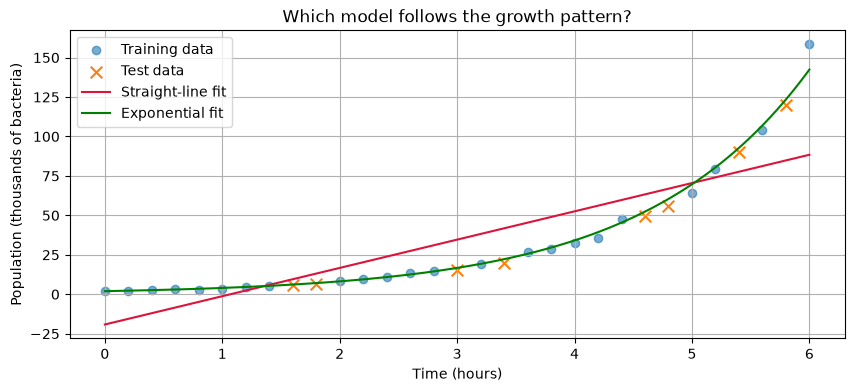

In [10]:
# Draw fitted curves across the observed time range.
time_grid = pd.DataFrame({"time_hours": np.linspace(0, 6, 200)})
plt.scatter(X_train["time_hours"], y_train, label="Training data", alpha=0.6)
plt.scatter(X_test["time_hours"], y_test, label="Test data", marker="x", s=70)
plt.plot(time_grid["time_hours"], linear_model.predict(time_grid),
         label="Straight-line fit", color="crimson")
plt.plot(time_grid["time_hours"], np.exp(log_model.predict(time_grid)),
         label="Exponential fit", color="green")
plt.title("Which model follows the growth pattern?")
plt.xlabel("Time (hours)")
plt.ylabel("Population (thousands of bacteria)")
plt.legend()
plt.show()

## 8. Residuals: actual minus predicted
A residual is the difference between an observation and its prediction. A positive residual means the model predicted too low. A negative residual means it predicted too high.

Below, **both plots use original population units and the same test observations**. A systematic curve can suggest a poorly captured relationship. There are few test points here, so these plots are an illustration rather than strong statistical evidence. Because we simulated proportional noise, original-scale errors may grow with population even when the growth curve is appropriate.

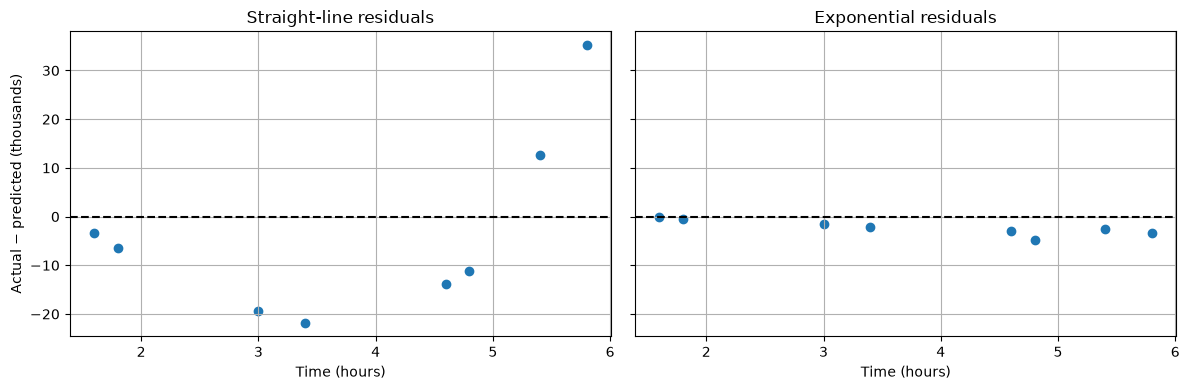

In [11]:
# Compare test residuals in the same units.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, title, predictions in [
    (axes[0], "Straight-line residuals", linear_predictions),
    (axes[1], "Exponential residuals", exponential_predictions)
]:
    ax.scatter(X_test["time_hours"], y_test.to_numpy() - predictions)
    ax.axhline(0, color="black", linestyle="--")
    ax.set(title=title, xlabel="Time (hours)")
axes[0].set_ylabel("Actual − predicted (thousands)")
plt.tight_layout()
plt.show()

## 9. Three talking points for the code walkthrough

**1 — Preparing the data**  
“Our dataset is a simulated bacteria population over six hours. Time is our input, and population is what we want to predict. We reserve some observations to evaluate the models.”

**2 — Transforming and training**  
“Bacteria multiply rather than increase by a fixed amount. This produces a curve. Taking the natural logarithm makes the pattern approximately straight, so we can train a linear regression model. We use the exponential function to convert its predictions back into population values.”

**3 — Evaluating the results**  
“We compare both models on the same test data and in the same population units. RMSE tells us how large the prediction errors are, and the graph shows which model follows the growth pattern. R-squared is not a percentage of accuracy.”

### Questions to practice
- Why must population values be positive before applying `np.log()`?
- What is the difference between adding two bacteria and doubling a population?
- Why do we use `np.exp()` after predicting log-population?
- Why might a straight-line model predict an impossible negative population?
- Why does this simulation not prove that real bacteria will grow forever?

### Conclusion
For this simulated exponential pattern, the log transformation lets a straight-line algorithm represent a growth curve. A transformation should be chosen because it suits the data and assumptions; it is not automatically appropriate for every regression dataset.